In [5]:
import pandas as pd
df = pd.read_excel('cleaned_dataset.xlsx')  # or .csv, matching whatever you uploaded
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [6]:
df['TotalPrice'].describe()

,TotalPrice
count,1200.000000
mean,1053.968300
std,819.856558
min,11.390000
25%,410.520000
50%,823.615000
75%,1578.475000
max,3456.400000


<Axes: >

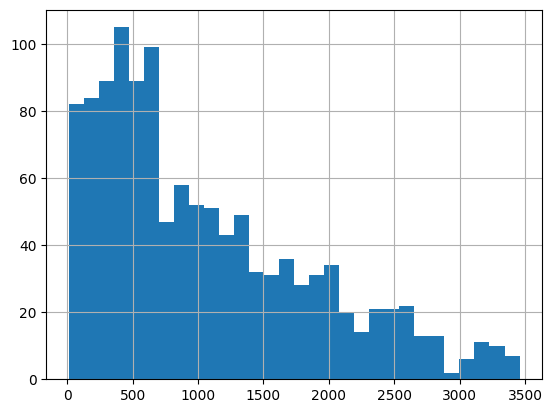

In [7]:
df['TotalPrice'].hist(bins=30)

In [8]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['TotalPrice'] < lower) | (df['TotalPrice'] > upper)]
print(lower, upper)
print(outliers.shape)

-1341.4125 3330.4075
(8, 14)


In [9]:
outliers[['OrderID','Product','Quantity','UnitPrice','TotalPrice','OrderStatus']]

,OrderID,Product,Quantity,UnitPrice,TotalPrice,OrderStatus
107,ORD200107,Printer,5,670.75,3353.75,Shipped
326,ORD200326,Laptop,5,670.48,3352.40,Returned
328,ORD200328,Tablet,5,674.04,3370.20,Cancelled
469,ORD200469,Chair,5,676.98,3384.90,Cancelled
632,ORD200632,Laptop,5,678.16,3390.80,Delivered
789,ORD200789,Tablet,5,691.28,3456.40,Delivered
1065,ORD201065,Printer,5,666.80,3334.00,Delivered
1122,ORD201122,Monitor,5,678.19,3390.95,Returned


In [10]:
df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].corr()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


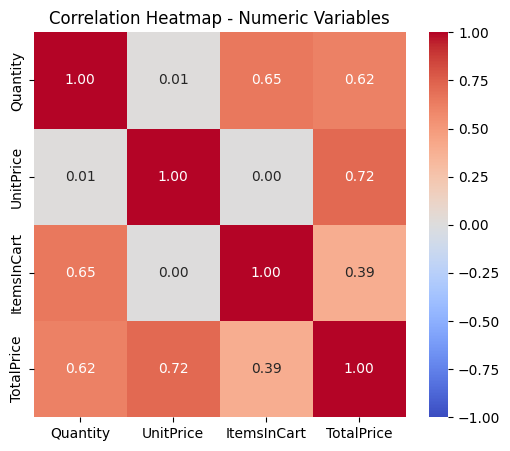

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Heatmap - Numeric Variables')
plt.show()